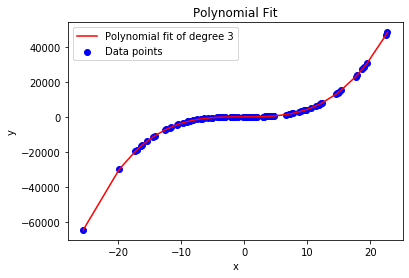

Polynomial Mean Squared Error: 7.7766
Polynomial R-squared: 1.0000


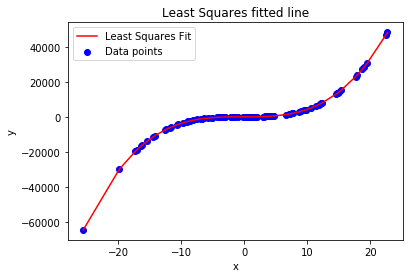

Least Squares Mean Squared Error: 7.7766
Least Squares R-squared: 1.0000

Method Comparison:
Least Squares is the better model

Part B: Testing multiple polynomial degrees
Degree 1
MSE: 46485644.7697
R-squared: 0.7166

Degree 2
MSE: 46347360.5837
R-squared: 0.7174

Degree 3
MSE: 7.7766
R-squared: 1.0000

Degree 4
MSE: 7.7483
R-squared: 1.0000

Degree 5
MSE: 7.5236
R-squared: 1.0000

Degree 6
MSE: 7.5213
R-squared: 1.0000

Degree 7
MSE: 7.5195
R-squared: 1.0000

Degree 8
MSE: 7.4012
R-squared: 1.0000

Degree 9
MSE: 7.3741
R-squared: 1.0000


Part C: Vandermonde Matrix


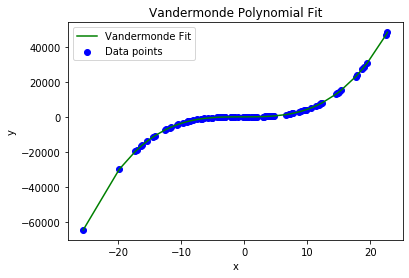

Vandermonde Mean Squared Error: 7.7766
Vandermonde R-squared: 1.0000


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x1 = np.random.randn(100)*10
x = np.sort(x1)
y = 4*x**3 + 3*x**2 + 2*x + 1 + np.random.rand(100) * 10

# ------------------
# polynomial method
# ------------------

degree = 3
coefficients = np.polyfit(x, y, degree)

polynomial = np.poly1d(coefficients)

y_pred = polynomial(x)

plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Mean Squared Error (MSE)
mse_poly = np.mean((y - y_pred)**2)
print(f'Polynomial Mean Squared Error: {mse_poly:.4f}')

# R-squared value
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r2_poly = 1 - (ss_res / ss_total)
print(f'Polynomial R-squared: {r2_poly:.4f}')


# --------------------
# Least squares method
# --------------------

A2 = np.vstack([x**3, x**2, x, np.ones(len(x))]).T

# solve
a, b, c, d = np.linalg.lstsq(A2, y, rcond=None)[0]

y_pred1 = a*x**3 + b*x**2 + c*x + d

plt.figure()
plt.scatter(x, y, color="blue", label="Data points")
plt.plot(x, y_pred1, color='red', label="Least Squares Fit")
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title("Least Squares fitted line")
plt.show()

# Mean Squared Error (MSE)
mse_lsq = np.mean((y - y_pred1)**2)
print(f'Least Squares Mean Squared Error: {mse_lsq:.4f}')

# R-squared value
ss_res = np.sum((y - y_pred1)**2)
r2_lsq = 1 - (ss_res / ss_total)
print(f'Least Squares R-squared: {r2_lsq:.4f}')


# ----------------------------
# Compare which method is best
# ----------------------------

print("\nMethod Comparison:")

if r2_poly > r2_lsq:
    print("Polynomial Fit is the better model")
else:
    print("Least Squares is the better model")


# ==================================================
# Part B
# crank degree up and down to show under/over fitting
# ==================================================

print("\nPart B: Testing multiple polynomial degrees")

for deg in range(1,10):

    coefficients = np.polyfit(x, y, deg)
    polynomial = np.poly1d(coefficients)

    y_test = polynomial(x)

    mse = np.mean((y - y_test)**2)

    ss_res = np.sum((y - y_test)**2)
    r_squared = 1 - (ss_res / ss_total)

    print(f"Degree {deg}")
    print(f"MSE: {mse:.4f}")
    print(f"R-squared: {r_squared:.4f}")
    print()


# =====================
# Part C - Vandermonde
# =====================

print("\nPart C: Vandermonde Matrix")

degree = 3

V = np.vander(x, degree+1)

coeffs_v = np.linalg.lstsq(V, y, rcond=None)[0]

y_v = coeffs_v[0]*x**3 + coeffs_v[1]*x**2 + coeffs_v[2]*x + coeffs_v[3]

plt.figure()
plt.scatter(x, y, color="blue", label="Data points")
plt.plot(x, y_v, color="green", label="Vandermonde Fit")
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title("Vandermonde Polynomial Fit")
plt.show()

# MSE
mse_v = np.mean((y - y_v)**2)
print(f'Vandermonde Mean Squared Error: {mse_v:.4f}')

# R^2
ss_res = np.sum((y - y_v)**2)
r2_v = 1 - (ss_res / ss_total)

print(f'Vandermonde R-squared: {r2_v:.4f}')